# 1. Introduction & Project Objectives

## Games Workshop Group plc — Python DCF Valuation Analysis

**Python-based financial modelling and intrinsic valuation**

This notebook independently analyses Games Workshop Group plc and recreates the core discounted cash flow (DCF) valuation developed in the accompanying Excel model.

### Objectives
- Analyse historical financial performance.
- Forecast revenue and operating profit using explicit analyst assumptions.
- Calculate NOPAT and unlevered free cash flow (UFCF).
- Discount forecast cash flows using WACC.
- Estimate terminal value using the Gordon Growth Method.
- Bridge enterprise value to equity value and calculate an implied share price.
- Verify core Excel valuation outputs against the Python implementation.
- Generate portfolio-ready financial charts and a DCF sensitivity heatmap.

### Data and modelling policy
Historical financial statement data is sourced from Games Workshop Group plc's published annual reports. Forecast and valuation assumptions are explicit analyst/model inputs and are **not company guidance**.

**Valuation reference date:** 1 June 2025  
**Forecast period:** FY2026–FY2030

### Units
Unless otherwise stated, financial figures are presented in **£ millions** and per-share values in **£ per share**.

# 2. Environment and Libraries

The analysis uses pandas for structured financial data, NumPy for numerical calculations and Matplotlib for portfolio-quality visualisations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# 3. Historical Financial Data

The historical dataset covers FY2021–FY2025 and includes revenue, operating profit, net income and basic EPS.

### Primary source
Games Workshop Group plc, **Annual Report 2024/25**, *Five Year Summary*, p.95.

**Source:** [Games Workshop Group plc — Annual Report 2024/25](https://assets.ctfassets.net/ost7hseic9hc/3kXsoA4jSOmOj6BLZ7bV7F/c34a5f56769e8be055c19b8e1ccc5526/Accounts_2024-25_FINAL.pdf)

In [2]:
# Source: Games Workshop Group plc, Annual Report 2024/25, Five Year Summary, p.95.
historical_df = pd.DataFrame({
    "Year": [2021, 2022, 2023, 2024, 2025],
    "Revenue (£m)": [369.5, 414.8, 470.8, 525.7, 617.5],
    "Operating Profit (£m)": [151.7, 157.1, 170.2, 201.8, 261.3],
    "Net Income (£m)": [122.0, 128.4, 134.7, 151.1, 196.1],
    "EPS (p)": [372.7, 391.3, 409.7, 458.8, 594.9]
})

historical_df

,Year,Revenue (£m),Operating Profit (£m),Net Income (£m),EPS (p)
0,2021,369.50,151.70,122.00,372.70
1,2022,414.80,157.10,128.40,391.30
2,2023,470.80,170.20,134.70,409.70
3,2024,525.70,201.80,151.10,458.80
4,2025,617.50,261.30,196.10,594.90


# 4. Historical Financial Analysis

Revenue growth, operating margin and net margin are calculated from the reported historical financial data. FY2021 revenue growth is shown as unavailable because FY2020 revenue is not included in the dataset.

In [3]:
historical_analysis_df = historical_df.copy()

historical_analysis_df["Revenue Growth"] = (
    historical_analysis_df["Revenue (£m)"].pct_change()
)

historical_analysis_df["Operating Margin"] = (
    historical_analysis_df["Operating Profit (£m)"]
    / historical_analysis_df["Revenue (£m)"]
)

historical_analysis_df["Net Margin"] = (
    historical_analysis_df["Net Income (£m)"]
    / historical_analysis_df["Revenue (£m)"]
)

historical_analysis_df

,Year,Revenue (£m),Operating Profit (£m),Net Income (£m),EPS (p),Revenue Growth,Operating Margin,Net Margin
0,2021,369.50,151.70,122.00,372.70,NaN,0.41,0.33
1,2022,414.80,157.10,128.40,391.30,0.12,0.38,0.31
2,2023,470.80,170.20,134.70,409.70,0.14,0.36,0.29
3,2024,525.70,201.80,151.10,458.80,0.12,0.38,0.29
4,2025,617.50,261.30,196.10,594.90,0.17,0.42,0.32


# 5. DCF Assumptions

| Assumption | Base Case | Classification |
|---|---:|---|
| WACC | 8.9% | Analyst assumption |
| Terminal growth | 2.0% | Analyst assumption |
| Tax rate | 25.0% | Modelling assumption |
| Forecast period | FY2026–FY2030 | Model structure |

The 25% tax assumption is informed by the UK corporation tax rate referenced in Games Workshop's FY2025 Annual Report, Note 10, p.80. It is used as a simplified forecast assumption; the Group's actual effective tax rate can differ.

In [4]:
# WACC and terminal growth are analyst/model assumptions; tax rate is informed by the FY2025 Annual Report's 25% UK corporation tax benchmark.
wacc = 0.089
terminal_growth = 0.020
tax_rate = 0.25

forecast_years = [2026, 2027, 2028, 2029, 2030]

dcf_assumptions = pd.DataFrame({
    "Assumption": [
        "WACC",
        "Terminal Growth Rate",
        "Tax Rate",
        "Forecast Period"
    ],
    "Value": [
        wacc,
        terminal_growth,
        tax_rate,
        "FY2026–FY2030"
    ]
})

dcf_assumptions

,Assumption,Value
0,WACC,0.09
1,Terminal Growth Rate,0.02
2,Tax Rate,0.25
3,Forecast Period,FY2026–FY2030


# 6. Revenue Growth Forecast

FY2025 actual revenue of **£617.5m** is the starting point. Forecast revenue growth rates are analyst/model assumptions and are not company guidance.

**Source for FY2025 actual revenue:** Games Workshop Group plc, Annual Report 2024/25, *Five Year Summary*, p.95.

In [5]:
# Analyst assumption: forecast revenue growth rates for FY2026–FY2030.
revenue_growth_df = pd.DataFrame({
    "Year": forecast_years,
    "Revenue Growth": [0.08, 0.07, 0.06, 0.05, 0.05]
})

revenue_2025 = 617.5

forecast_revenue = []
previous_revenue = revenue_2025

for growth in revenue_growth_df["Revenue Growth"]:
    previous_revenue = previous_revenue * (1 + growth)
    forecast_revenue.append(previous_revenue)

revenue_forecast_df = pd.DataFrame({
    "Year": forecast_years,
    "Revenue (£m)": forecast_revenue,
    "Revenue Growth": revenue_growth_df["Revenue Growth"]
})

revenue_forecast_df

,Year,Revenue (£m),Revenue Growth
0,2026,666.90,0.08
1,2027,713.58,0.07
2,2028,756.40,0.06
3,2029,794.22,0.05
4,2030,833.93,0.05


# 7. Operating Profit Forecast

Forecast operating profit is derived by applying a **29.0% operating margin** to forecast revenue. This is an analyst/model assumption and is not presented as Games Workshop guidance.

In [6]:
# Analyst assumption: constant 29.0% operating margin for FY2026–FY2030.
forecast_operating_margin = 0.29

operating_profit_forecast_df = pd.DataFrame({
    "Year": forecast_years,
    "Operating Margin": [forecast_operating_margin] * len(forecast_years)
})

operating_profit_forecast_df["Operating Profit (£m)"] = (
    revenue_forecast_df["Revenue (£m)"]
    * operating_profit_forecast_df["Operating Margin"]
)

operating_profit_forecast_df

,Year,Operating Margin,Operating Profit (£m)
0,2026,0.29,193.40
1,2027,0.29,206.94
2,2028,0.29,219.36
3,2029,0.29,230.32
4,2030,0.29,241.84


# 8. Tax and NOPAT

NOPAT (Net Operating Profit After Tax) converts forecast operating profit into an after-tax operating profit measure before financing effects.

**NOPAT = Operating Profit × (1 − Tax Rate)**

The 25% tax rate is a modelling assumption informed by the UK corporation tax benchmark disclosed in Games Workshop's FY2025 Annual Report, Note 10, p.80.

In [7]:
nopat_df = operating_profit_forecast_df[["Year", "Operating Profit (£m)"]].copy()

nopat_df["Tax (£m)"] = (
    nopat_df["Operating Profit (£m)"] * tax_rate
)

nopat_df["NOPAT (£m)"] = (
    nopat_df["Operating Profit (£m)"] - nopat_df["Tax (£m)"]
)

nopat_df

,Year,Operating Profit (£m),Tax (£m),NOPAT (£m)
0,2026,193.40,48.35,145.05
1,2027,206.94,51.73,155.20
2,2028,219.36,54.84,164.52
3,2029,230.32,57.58,172.74
4,2030,241.84,60.46,181.38


# 9. Unlevered Free Cash Flow

UFCF represents cash flow available to all capital providers before financing effects.

**UFCF = NOPAT + D&A − Capex − Change in NWC**

Only FY2026–FY2030 forecast cash flows are included in the DCF valuation. D&A, Capex and changes in NWC are explicit analyst/model assumptions.

In [8]:
# Analyst assumptions: D&A, Capex and change in NWC for FY2026–FY2030.
# Forecast operating cash-flow assumptions (£m)
# These are explicit analyst/model assumptions rather than reported company guidance.
depreciation = [32, 34, 36, 38, 40]
capex = [37, 39, 41, 43, 45]
change_nwc = [5, 5, 5, 5, 5]

ufcf_df = nopat_df[["Year", "NOPAT (£m)"]].copy()
ufcf_df["D&A (£m)"] = depreciation
ufcf_df["Capex (£m)"] = capex
ufcf_df["Change in NWC (£m)"] = change_nwc

ufcf_df["UFCF (£m)"] = (
    ufcf_df["NOPAT (£m)"]
    + ufcf_df["D&A (£m)"]
    - ufcf_df["Capex (£m)"]
    - ufcf_df["Change in NWC (£m)"]
)

ufcf_df


,Year,NOPAT (£m),D&A (£m),Capex (£m),Change in NWC (£m),UFCF (£m)
0,2026,145.05,32,37,5,135.05
1,2027,155.20,34,39,5,145.20
2,2028,164.52,36,41,5,154.52
3,2029,172.74,38,43,5,162.74
4,2030,181.38,40,45,5,171.38


# 10. Terminal Value and Discounted Cash Flow

Forecast UFCF is discounted to the FY2025 valuation date using the 8.9% WACC.

Terminal value is estimated using the Gordon Growth Method:

**Terminal Value = Final Year UFCF × (1 + g) / (WACC − g)**

The terminal value is then discounted to present value.

In [9]:
# DCF mechanics: discount forecast UFCF to the FY2025 valuation date using the WACC.
# Discount forecast UFCF
discount_factors = [
    1 / ((1 + wacc) ** period)
    for period in range(1, len(forecast_years) + 1)
]

dcf_df = ufcf_df[["Year", "UFCF (£m)"]].copy()
dcf_df["Discount Factor"] = discount_factors
dcf_df["PV of UFCF (£m)"] = (
    dcf_df["UFCF (£m)"] * dcf_df["Discount Factor"]
)

dcf_df

,Year,UFCF (£m),Discount Factor,PV of UFCF (£m)
0,2026,135.05,0.92,124.01
1,2027,145.20,0.84,122.44
2,2028,154.52,0.77,119.64
3,2029,162.74,0.71,115.71
4,2030,171.38,0.65,111.90


In [10]:
# DCF mechanics: calculate terminal value using the Gordon Growth Method and derive enterprise value.
final_ufcf = ufcf_df["UFCF (£m)"].iloc[-1]

terminal_value = (
    final_ufcf * (1 + terminal_growth)
    / (wacc - terminal_growth)
)

pv_terminal_value = (
    terminal_value * discount_factors[-1]
)

pv_forecast_ufcf = dcf_df["PV of UFCF (£m)"].sum()

enterprise_value = (
    pv_forecast_ufcf + pv_terminal_value
)

terminal_value_summary = pd.DataFrame({
    "Metric": [
        "Final Forecast UFCF",
        "Terminal Growth Rate",
        "WACC",
        "Terminal Value",
        "PV of Terminal Value",
        "PV of Forecast UFCF",
        "Enterprise Value"
    ],
    "Value": [
        final_ufcf,
        terminal_growth,
        wacc,
        terminal_value,
        pv_terminal_value,
        pv_forecast_ufcf,
        enterprise_value
    ]
})

terminal_value_summary

,Metric,Value
0,Final Forecast UFCF,171.38
1,Terminal Growth Rate,0.02
2,WACC,0.09
3,Terminal Value,"2,533.44"
4,PV of Terminal Value,"1,654.13"
5,PV of Forecast UFCF,593.71
6,Enterprise Value,"2,247.84"


# 11. Equity Value and Implied Share Price

Enterprise value is bridged to equity value using FY2025 balance-sheet and share-count inputs.

- Cash: **£132.6m**
- Lease liabilities: **£45.2m**
- Issued shares: **32.972m**

**Source:** Games Workshop Group plc, Annual Report 2024/25, pp.71, 89–90 (Notes 22, 28 and 31).

In [11]:
# Source inputs at 1 June 2025: cash £132.6m (p.71/Note 22), lease liabilities £45.2m (p.90/Note 31), issued shares 32.972m (p.89/Note 28).
cash = 132.6
lease_liabilities = 45.2
shares_outstanding_m = 32.972

equity_value = enterprise_value + cash - lease_liabilities

implied_share_price = (
    equity_value / shares_outstanding_m
)

equity_value_summary = pd.DataFrame({
    "Metric": [
        "Enterprise Value (£m)",
        "Cash (£m)",
        "Lease Liabilities (£m)",
        "Equity Value (£m)",
        "Shares Outstanding (m)",
        "Implied Share Price (£)"
    ],
    "Value": [
        enterprise_value,
        cash,
        lease_liabilities,
        equity_value,
        shares_outstanding_m,
        implied_share_price
    ]
})

equity_value_summary


,Metric,Value
0,Enterprise Value (£m),"2,247.84"
1,Cash (£m),132.60
2,Lease Liabilities (£m),45.20
3,Equity Value (£m),"2,335.24"
4,Shares Outstanding (m),32.97
5,Implied Share Price (£),70.83


# 12. Excel vs Python Verification

A key objective is to demonstrate that Python can independently reproduce the core valuation outputs of the Excel model. Enter the final Excel figures from the completed workbook in the three variables below; the table then calculates the differences automatically.

A blank Excel value is intentionally shown as `NaN` rather than inventing a reconciliation figure.

In [12]:
# Enter the final Excel outputs from the completed DCF workbook here.
excel_enterprise_value = None
excel_equity_value = None
excel_implied_share_price = None

python_enterprise_value = enterprise_value
python_equity_value = equity_value
python_implied_share_price = implied_share_price

verification = pd.DataFrame({
    "Metric": ["Enterprise Value (£m)", "Equity Value (£m)", "Implied Share Price (£)"],
    "Excel": [excel_enterprise_value, excel_equity_value, excel_implied_share_price],
    "Python": [python_enterprise_value, python_equity_value, python_implied_share_price]
})
verification["Difference"] = verification["Python"] - verification["Excel"]
verification

,Metric,Excel,Python,Difference
0,Enterprise Value (£m),None,"2,247.84",NaN
1,Equity Value (£m),None,"2,335.24",NaN
2,Implied Share Price (£),None,70.83,NaN


# 13. DCF Sensitivity Analysis

The sensitivity analysis varies WACC and terminal growth to show how the implied share price changes under alternative valuation assumptions. The base case is **8.9% WACC / 2.0% terminal growth**.

In [13]:
wacc_values = [0.079, 0.084, 0.089, 0.094, 0.099]
terminal_growth_values = [0.010, 0.015, 0.020, 0.025, 0.030]

sensitivity_results = []

for sensitivity_wacc in wacc_values:
    row = []

    for sensitivity_growth in terminal_growth_values:
        sensitivity_discount_factors = [
            1 / ((1 + sensitivity_wacc) ** period)
            for period in range(1, len(ufcf_df) + 1)
        ]

        pv_forecast = sum(
            ufcf * discount_factor
            for ufcf, discount_factor in zip(
                ufcf_df["UFCF (£m)"],
                sensitivity_discount_factors
            )
        )

        sensitivity_terminal_value = (
            final_ufcf * (1 + sensitivity_growth)
            / (sensitivity_wacc - sensitivity_growth)
        )

        sensitivity_pv_terminal = (
            sensitivity_terminal_value
            * sensitivity_discount_factors[-1]
        )

        sensitivity_enterprise_value = (
            pv_forecast + sensitivity_pv_terminal
        )

        sensitivity_equity_value = (
            sensitivity_enterprise_value + cash - lease_liabilities
        )

        sensitivity_price = (
            sensitivity_equity_value / shares_outstanding_m
        )

        row.append(sensitivity_price)

    sensitivity_results.append(row)

sensitivity_df = pd.DataFrame(
    sensitivity_results,
    index=[f"{x:.1%}" for x in wacc_values],
    columns=[f"{x:.1%}" for x in terminal_growth_values]
)

sensitivity_df.index.name = "WACC"
sensitivity_df.columns.name = "Terminal Growth"

sensitivity_df.round(2)

Terminal Growth,1.0%,1.5%,2.0%,2.5%,3.0%
WACC,,,,,
7.9%,73.18,77.52,82.60,88.61,95.86
8.4%,68.30,71.99,76.25,81.23,87.14
8.9%,64.05,67.21,70.83,75.01,79.90
9.4%,60.30,63.03,66.13,69.69,73.80
9.9%,56.97,59.36,62.04,65.09,68.58


# 14. Portfolio Visualisations

The project brief requires four Python-generated charts. Each is generated directly from the model data so that the analysis is reproducible.

## Chart 1 — Historical Revenue Growth

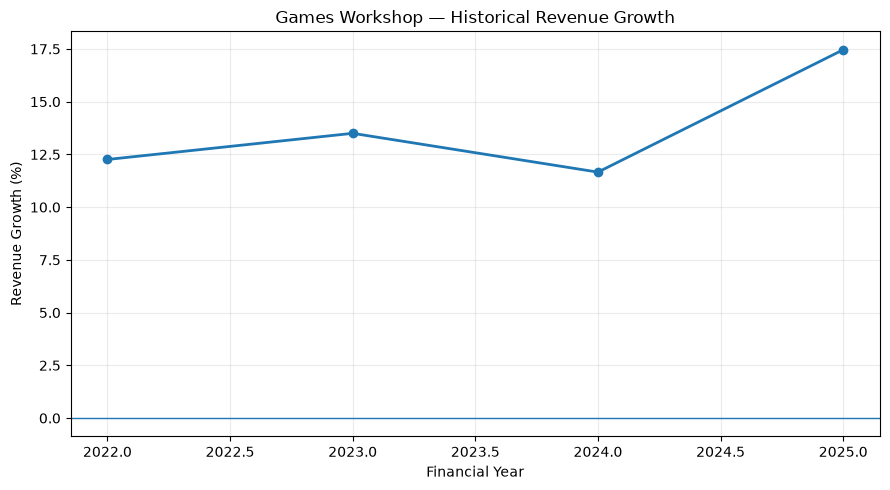

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(historical_analysis_df["Year"], historical_analysis_df["Revenue Growth"] * 100, marker="o", linewidth=2)
ax.set_title("Games Workshop — Historical Revenue Growth")
ax.set_xlabel("Financial Year")
ax.set_ylabel("Revenue Growth (%)")
ax.axhline(0, linewidth=1)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Chart 2 — Historical Margin Trends

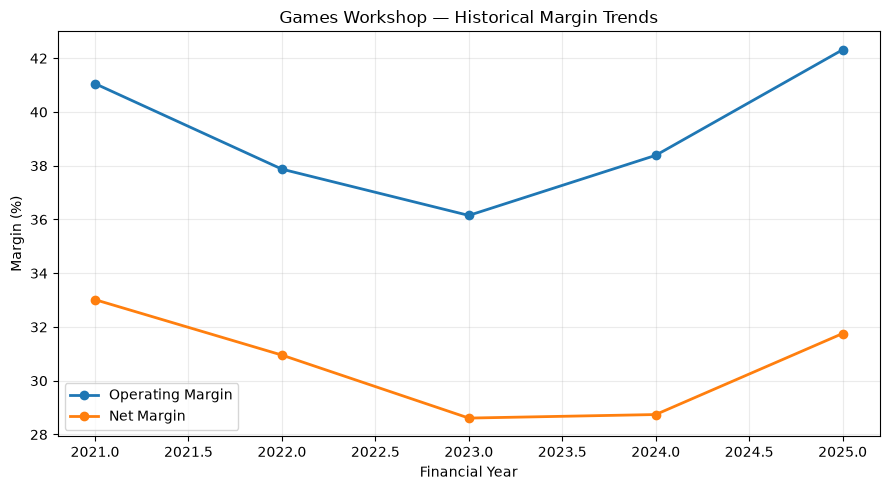

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(historical_analysis_df["Year"], historical_analysis_df["Operating Margin"] * 100, marker="o", linewidth=2, label="Operating Margin")
ax.plot(historical_analysis_df["Year"], historical_analysis_df["Net Margin"] * 100, marker="o", linewidth=2, label="Net Margin")
ax.set_title("Games Workshop — Historical Margin Trends")
ax.set_xlabel("Financial Year")
ax.set_ylabel("Margin (%)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Chart 3 — Forecast Unlevered Free Cash Flow

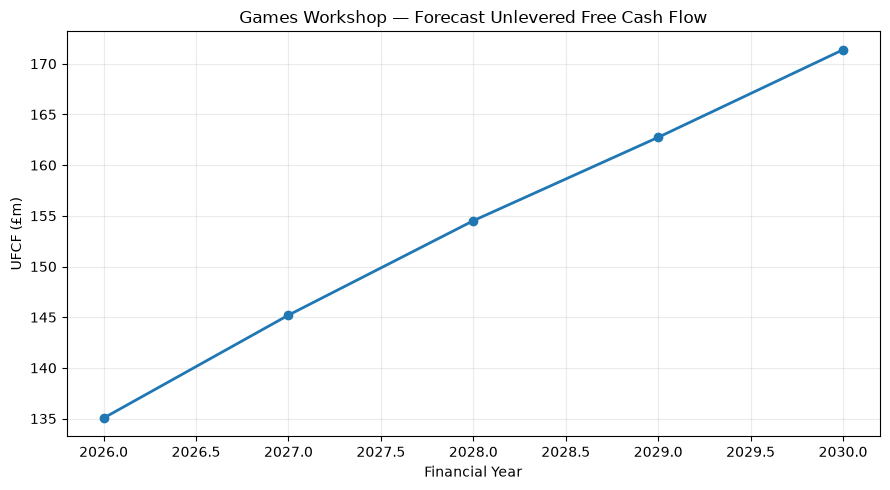

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ufcf_df["Year"], ufcf_df["UFCF (£m)"], marker="o", linewidth=2)
ax.set_title("Games Workshop — Forecast Unlevered Free Cash Flow")
ax.set_xlabel("Financial Year")
ax.set_ylabel("UFCF (£m)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Chart 4 — DCF Sensitivity Heatmap

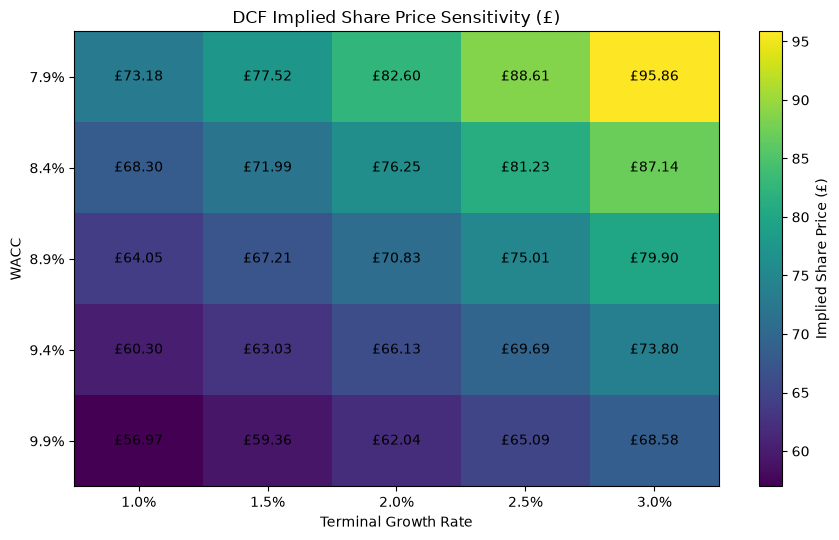

In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5))
image = ax.imshow(sensitivity_df.values, aspect="auto")
ax.set_xticks(range(len(sensitivity_df.columns)))
ax.set_xticklabels(sensitivity_df.columns)
ax.set_yticks(range(len(sensitivity_df.index)))
ax.set_yticklabels(sensitivity_df.index)
ax.set_xlabel("Terminal Growth Rate")
ax.set_ylabel("WACC")
ax.set_title("DCF Implied Share Price Sensitivity (£)")
for i in range(sensitivity_df.shape[0]):
    for j in range(sensitivity_df.shape[1]):
        ax.text(j, i, f"£{sensitivity_df.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="Implied Share Price (£)")
plt.tight_layout()
plt.show()

# 15. Conclusion, Methodology and Sources

## Conclusion

The Python implementation provides an independent analytical framework for assessing Games Workshop's historical performance and DCF valuation. The sensitivity analysis demonstrates that intrinsic value is highly dependent on WACC and terminal growth assumptions.

## Methodology and Limitations

- Historical financial data is taken from Games Workshop's published annual reports.
- Forecast revenue growth, operating margin, D&A, Capex and NWC assumptions are analyst/model inputs.
- The forecast is deliberately simplified and is not a full bottom-up operating model.
- Terminal value can represent a significant proportion of enterprise value and is therefore sensitive to WACC and terminal growth.
- The valuation is anchored to FY2025 balance-sheet and share-count information at 1 June 2025.
- This notebook is a portfolio demonstration and is **not investment advice**.

## Sources and References

### Primary company sources

1. **Games Workshop Group plc — Annual Report 2024/25**, covering the 52 weeks ended 1 June 2025. Historical five-year summary: p.95; cash: p.71 / Note 22; taxation: p.80 / Note 10; issued shares: p.89 / Note 28; lease liabilities and net funds: p.90 / Note 31.
   [Annual Report PDF](https://assets.ctfassets.net/ost7hseic9hc/3kXsoA4jSOmOj6BLZ7bV7F/c34a5f56769e8be055c19b8e1ccc5526/Accounts_2024-25_FINAL.pdf)

2. **Games Workshop Group plc — Annual Report 2023/24**
   [Annual Report PDF](https://assets.ctfassets.net/ost7hseic9hc/6nhjgj1BVPlaTocG6L4IbS/e42b72a50979ca58769b9e85e04ae79a/2023-24_accounts_-_final.pdf)

3. **Games Workshop Group plc — Annual Report 2022/23**
   [Annual Report PDF](https://assets.ctfassets.net/ost7hseic9hc/3Bxadr0YTIX0hGl1H7DPGe/8e1361726a8e0c8dfef9bcdae8299480/2022-23_accounts_-_final.pdf)

4. **Games Workshop Group plc — Annual Report 2021/22**
   [Annual Report PDF](https://assets.ctfassets.net/ost7hseic9hc/4wT1AjfBUUX6HWQ0HhAAnu/ac4403cd600cef16674bfa20462a280b/2021-22-accounts-Final-NoM.pdf)

5. **Games Workshop Group plc — Investor Relations: Annual Reports and Half Year Results**
   [Investor Relations report archive](https://investor.games-workshop.com/annual-reports-and-half-year-results)

### Modelling sources

WACC, terminal growth, forecast revenue growth, operating margin, D&A, Capex and changes in NWC are explicit analyst/model assumptions carried forward from the working DCF model. They should not be interpreted as Games Workshop management guidance.

### Source convention

Figures taken directly from company filings are identified as **reported/source data**. Forecast assumptions and valuation parameters are identified as **analyst/model assumptions**.